# AG-HYPOPT · Trial 14

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Thirteen trials recorded, objective order: trial_09 0.1657 (BEST), trial_05 0.1863, trial_11 0.1883, trial_01 0.1907, trial_07 0.1940, trial_12 0.1941, trial_13 0.1941, trial_08 0.1948, trial_04 0.1987, trial_02 0.2075, trial_06 0.2203, trial_03 0.2472, trial_10 0.3727 (worst). Recap: mu_fit is pinned at ~half of mu_true for every config (objective floor); the objective is the gamma term, dominated by low transmission, and it is highly unstable. Trials 07, 12, 13 have formed a stable ~0.194 mid-pack plateau across a broad high-sigma_ref / high-lr_gamma band, well above the isolated 0.1657 best of trial_09 -- whose recipe was sigma_ref 25.0, lr_mu 6.55, lr_gamma 0.884, anneal 0.410. TPE (13/5) is exploiting. Context only.


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_14'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 20    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (13/5 trials)
ID |     ei | params
 1 | 0.3992 | {"gamma_anneal": 0.3120753412600538, "lr_gamma": 0.7306599179345346, "lr_mu": 22.789693889466186, "sigma_ref": 25.0}
 2 | 1.3404 | {"gamma_anneal": 0.3472068914413654, "lr_gamma": 0.8116678741093124, "lr_mu": 28.657293344219852, "sigma_ref": 25.0}
 3 | 2.7406 | {"gamma_anneal": 0.48764563563539154, "lr_gamma": 0.9357882730999053, "lr_mu": 7.322279506154903, "sigma_ref": 12.563952902064445}
 4 | 2.8825 | {"gamma_anneal": 0.6153545414493528, "lr_gamma": 0.8970587074805996, "lr_mu": 5.736670970523138, "sigma_ref": 23.871826530533255}
 5 | 2.9651 | {"gamma_anneal": 0.3785793539630544, "lr_gamma": 0.9988609499704584, "lr_mu": 11.827757685509733, "sigma_ref": 25.0}
 6 | 0.8970 | {"gamma_anneal": 0.1379754038882086, "lr_gamma": 0.8550987059497606, "lr_mu": 15.749804076894574, "sigma_ref": 17.814207141808506}
 7 | 1.8852 | {"gamma_anneal": 0.6852137222865615, "lr_gamma": 0.9681221202620132, "lr_mu": 10.714881290369142, "sigma_ref

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

TPE (13/5) ranks by expected improvement. The two highest-EI candidates, 5 (EI 2.97) and 8 (EI 2.94), both push parameters onto the space boundary (candidate 5: sigma_ref 25.0 and lr_gamma 0.999; candidate 8: sigma_ref 25.0 and lr_mu 5.0), i.e. extrapolations beyond the tested box. The next, candidate 4 (EI 2.88), is fully interior and is the closest match in the whole slate to the proven-best recipe: sigma_ref 23.87, lr_mu 5.74, lr_gamma 0.897, anneal 0.615 -- near trial_09's (25.0, 6.55, 0.884, 0.410) on all four knobs. Given the evidence that the best result came from exactly that interior region and that boundary extrapolations of the unstable gamma term have repeatedly blown up, candidate 4 makes the most sense. I choose candidate 4.


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 4               # closest interior replication of the best recipe, high EI, no boundary extrapolation


chosen: {'gamma_anneal': 0.6153545414493528, 'lr_gamma': 0.8970587074805996, 'lr_mu': 5.736670970523138, 'sigma_ref': 23.871826530533255}
Running  1nW Trans05 ... 

μ 9.39 -> 4.70 | γ 8.5 -> 4.65 | NLL 1.30


Running  1nW Trans20 ... 

μ 17.32 -> 8.66 | γ 8.5 -> 4.01 | NLL 2.91


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 51.25 | γ 14.1 -> 13.45 | NLL 2.76


Running 3nW Trans100 ... 

μ 175.71 -> 87.12 | γ 14.1 -> 13.91 | NLL 3.55



Total: 2.4 min


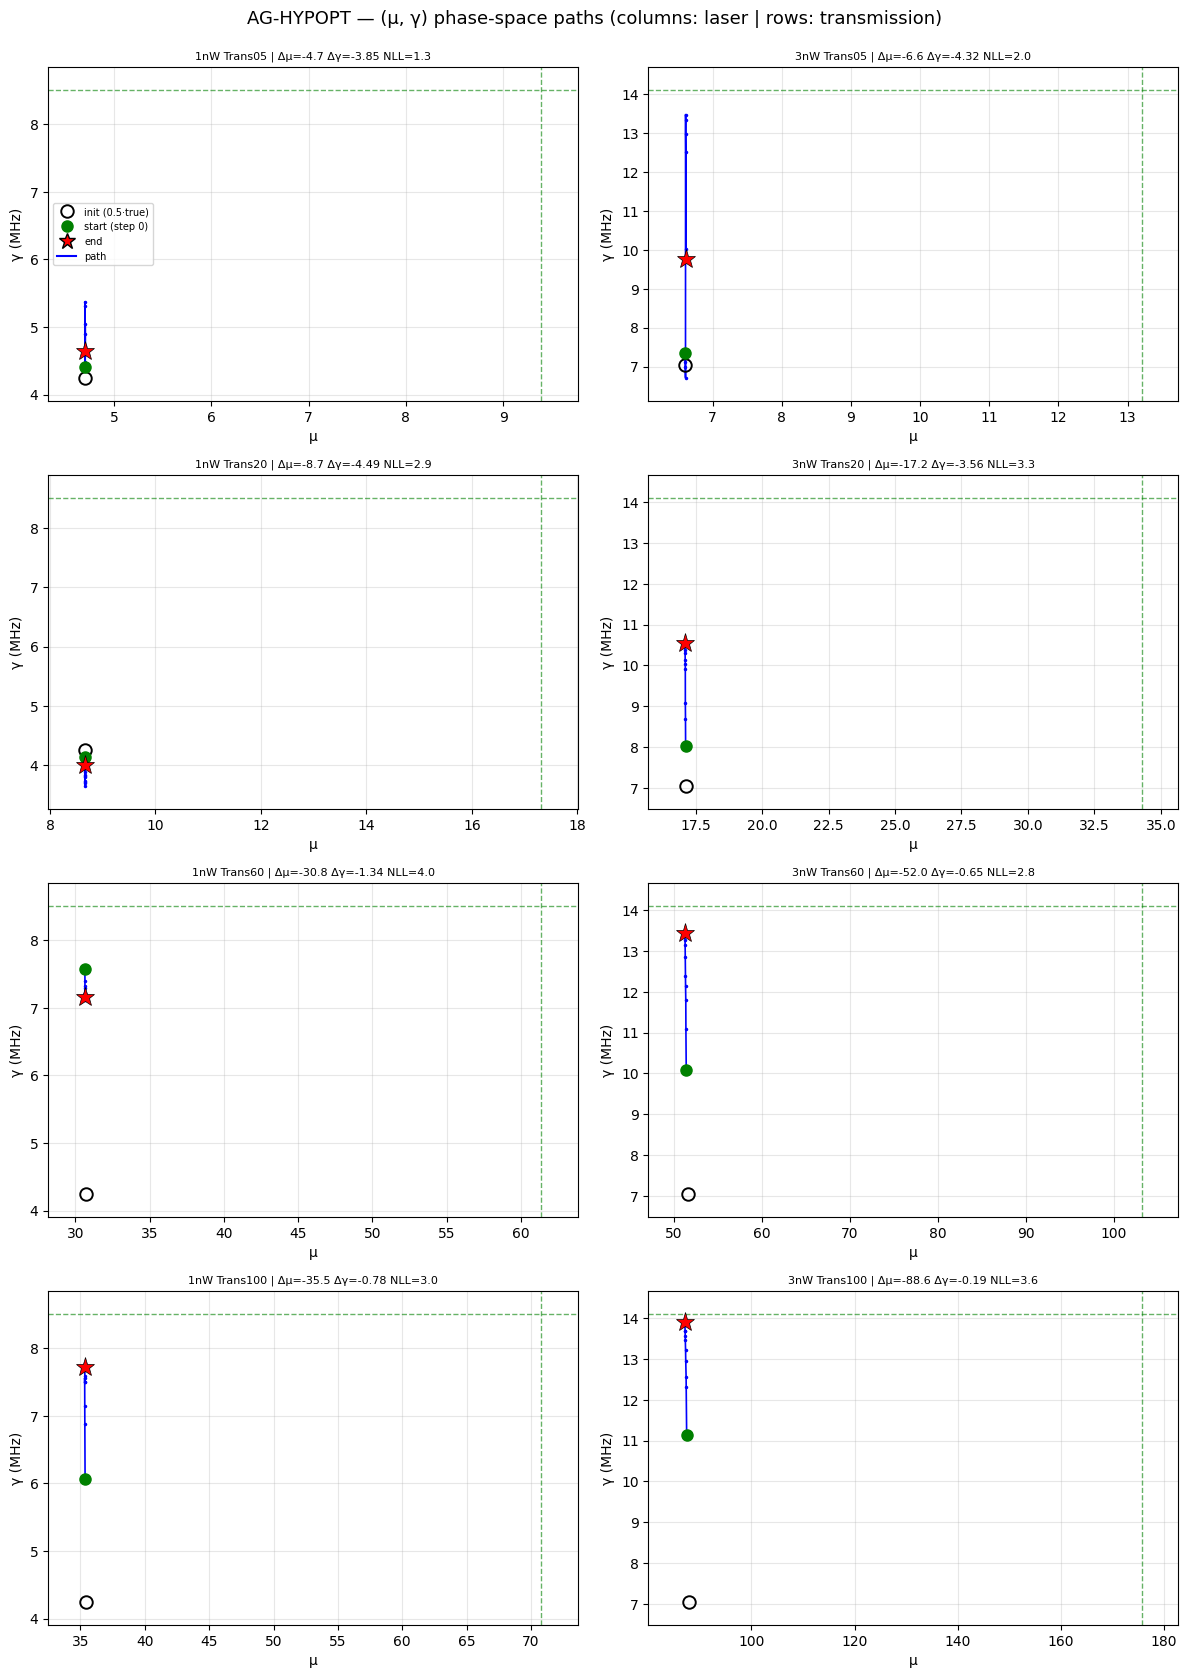

trial finished in 2.4 min
objective = 0.1679 ± 0.0279
exp           μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05     9.39    4.70   -49.9 |     8.50    4.65   -45.3
1nW Trans20    17.32    8.66   -50.0 |     8.50    4.01   -52.8
1nW Trans60    61.37   30.62   -50.1 |     8.50    7.16   -15.7
1nW Trans100   70.82   35.34   -50.1 |     8.50    7.72    -9.2
3nW Trans05    13.20    6.61   -49.9 |    14.10    9.78   -30.7
3nW Trans20    34.28   17.10   -50.1 |    14.10   10.54   -25.2
3nW Trans60   103.20   51.25   -50.3 |    14.10   13.45    -4.6
3nW Trans100  175.71   87.12   -50.4 |    14.10   13.91    -1.3

μ: RMSE 40.598 (rel 50.1%, bias -30.484) | γ: RMSE 2.942 (rel 29.1%, bias -2.398)


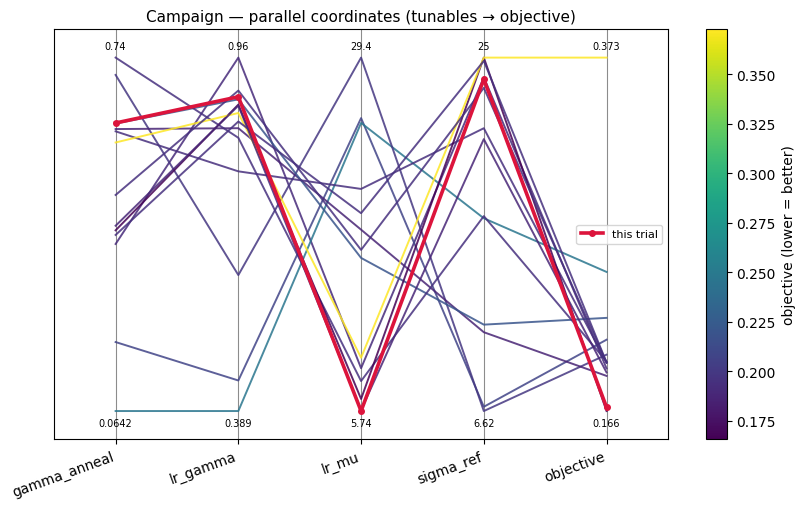

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 14, ninth TPE-driven trial; chosen as the closest interior replication of the best recipe: sigma_ref 23.87, lr_mu 5.74, lr_gamma 0.897, gamma_anneal 0.615. Result: objective 0.1679 +/- 0.0279 -- the SECOND-best of the campaign, essentially matching trial_09 (0.1657); runtime 2.4 min. mu_fit is unchanged at a uniform ~half-truth (Delta-mu% -49.9 to -50.4; mu RMSE 40.60, relative 50.1%). gamma_fit is strong: high transmission near-truth (3 nW Trans60/100: -4.6/-1.3%; 1 nW Trans100 -9.2%) and low transmission partly rescued (3 nW Trans05 -30.7%), though 1 nW Trans05/Trans20 remain poor (-45.3%/-52.8%); gamma RMSE 2.94 (relative 29.1%). So this config reproduces the good behaviour of trial_09 with a somewhat higher anneal.

**Summary:** Trial 14 (sigma_ref 23.87, lr_mu 5.74, lr_gamma 0.897, gamma_anneal 0.615) -> objective 0.1679 +/- 0.0279, second best, essentially matching trial_09; gamma RMSE 29.1% with 3 nW Trans05 rescued to -31%.
**Key insight:** The interior high-sigma_ref / low-lr_mu / high-lr_gamma region now has two consistently good draws (trial_09 0.1657, trial_14 0.1679), identifying it as the campaign's reproducible sweet spot, while boundary extrapolations of the same knobs blow up.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
No new structural notes; the real-data attractor note from trial_01 still stands.


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'Trial 14 (sigma_ref 23.87, lr_mu 5.74, lr_gamma 0.897, gamma_anneal 0.615): objective 0.1679 +/- 0.0279, second best, essentially matching trial_09; gamma RMSE 29.1% with 3 nW Trans05 rescued to -31%'
KEY_INSIGHT = 'The interior high-sigma_ref / low-lr_mu / high-lr_gamma region now has two consistently good draws (trial_09 0.1657, trial_14 0.1679) -- the campaign sweet spot -- while boundary extrapolations of the same knobs blow up.'


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_14 | current best: trial_09


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_15.ipynb. Open it and follow its cells from the top.
